## Лабораторна робота 3 


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Бібліотеки завантажено успішно.')

Бібліотеки завантажено успішно.


## Обрати унікальний датасет з https://archive.ics.uci.edu/datasets , який відповідає наступним вимогам:
Dataset Characteristics: Multivariate
Attribute Characteristics: Categorical, Integer, Real
Number of Attributes: at least 2 integers/real
Has Missing Values: Yes
Можна обрати датасет з інших ресурсів, але з цими ж вимогами. 
Я обрала Heart Disease https://archive.ics.uci.edu/dataset/45/heart+disease

## Завантаження датасету

In [6]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)


df.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]


df['disease'] = (df['target'] > 0).astype(int)

print('Розмір датасету:', df.shape)
df.head()

Розмір датасету: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


## Здійснити Data Cleaning

In [7]:

missing_before = df.isnull().sum().sum()
print(f'Пропущених значень до очищення: {missing_before}')


for col in ['ca', 'thal']:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: заповнено {n_missing} пропусків → медіана = {median_val}')


dups = df.duplicated().sum()
print(f'Дублікатів: {dups}')
df.drop_duplicates(inplace=True)


cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'disease']
for col in cat_cols:
    df[col] = df[col].astype(int)

missing_after = df.isnull().sum().sum()
print(f'\nПропущених значень після очищення: {missing_after}')
print(f'Записів після очищення: {len(df)}')
print(' Типи даних ')
print(df.dtypes)
print()
print('Пропущені значення')
print(df.isnull().sum())
print()
print(' Статистика')
df.describe()

Пропущених значень до очищення: 6
  ca: заповнено 4 пропусків → медіана = 0.0
  thal: заповнено 2 пропусків → медіана = 3.0
Дублікатів: 0

Пропущених значень після очищення: 0
Записів після очищення: 303
 Типи даних 
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
disease       int64
dtype: object

Пропущені значення
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
disease     0
dtype: int64

 Статистика


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,disease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


## Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

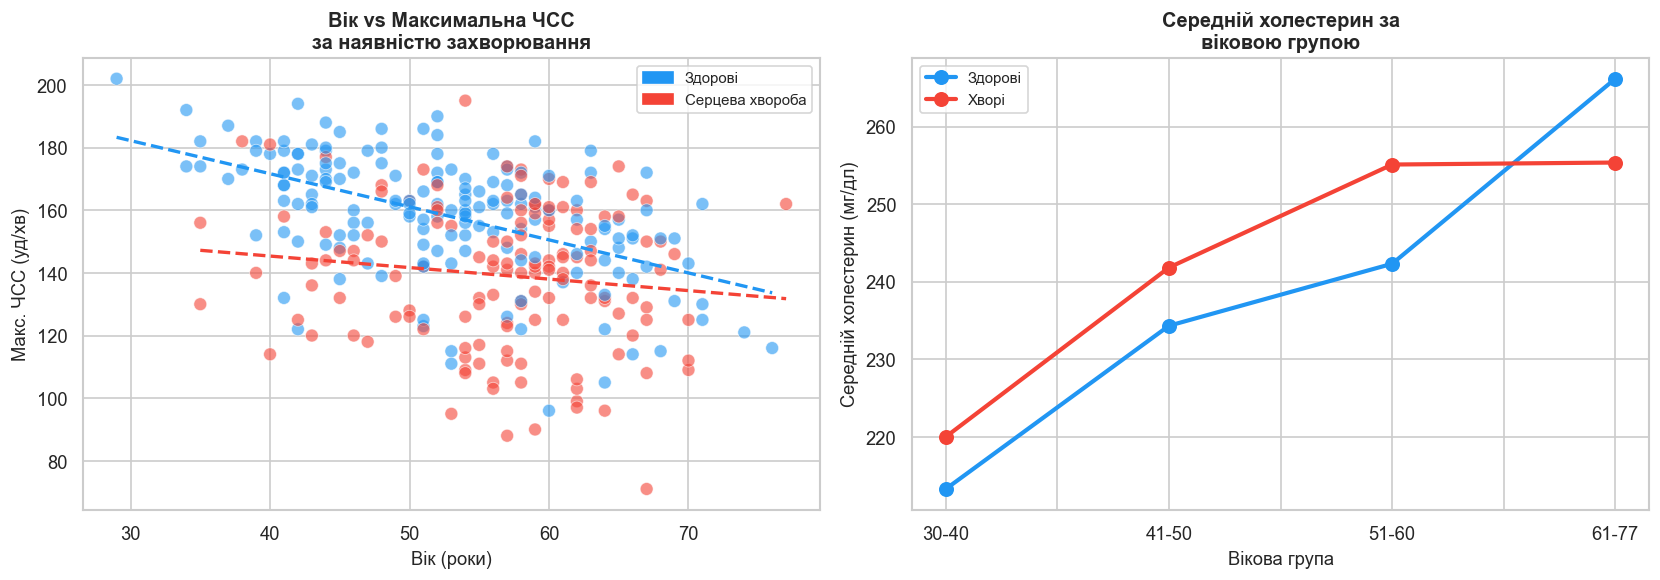

Графік збережено: plot1_scatter_lineplot.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = df['disease'].map({0: '#2196F3', 1: '#F44336'})
ax.scatter(df['age'], df['thalach'], c=colors, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)

for disease_val, color, label in [(0, '#2196F3', 'Здорові'), (1, '#F44336', 'Хворі')]:
    subset = df[df['disease'] == disease_val]
    z = np.polyfit(subset['age'], subset['thalach'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['age'].min(), subset['age'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')

ax.set_xlabel('Вік (роки)', fontsize=11)
ax.set_ylabel('Макс. ЧСС (уд/хв)', fontsize=11)
ax.set_title('Вік vs Максимальна ЧСС\nза наявністю захворювання', fontsize=12, fontweight='bold')
patch_h = mpatches.Patch(color='#2196F3', label='Здорові')
patch_d = mpatches.Patch(color='#F44336', label='Серцева хвороба')
ax.legend(handles=[patch_h, patch_d], fontsize=9)

ax2 = axes[1]
age_bins = pd.cut(df['age'], bins=[29, 40, 50, 60, 77], labels=['30-40', '41-50', '51-60', '61-77'])
df['age_group'] = age_bins
chol_by_age = df.groupby(['age_group', 'disease'], observed=True)['chol'].mean().unstack()
chol_by_age.columns = ['Здорові', 'Хворі']
chol_by_age.plot(ax=ax2, marker='o', linewidth=2.5, markersize=8, color=['#2196F3', '#F44336'])

ax2.set_xlabel('Вікова група', fontsize=11)
ax2.set_ylabel('Середній холестерин (мг/дл)', fontsize=11)
ax2.set_title('Середній холестерин за\nвіковою групою', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot1_scatter_lineplot.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot1_scatter_lineplot.png')

## Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.
У моєму випадку гістограма холестерину з 5 діапазонами

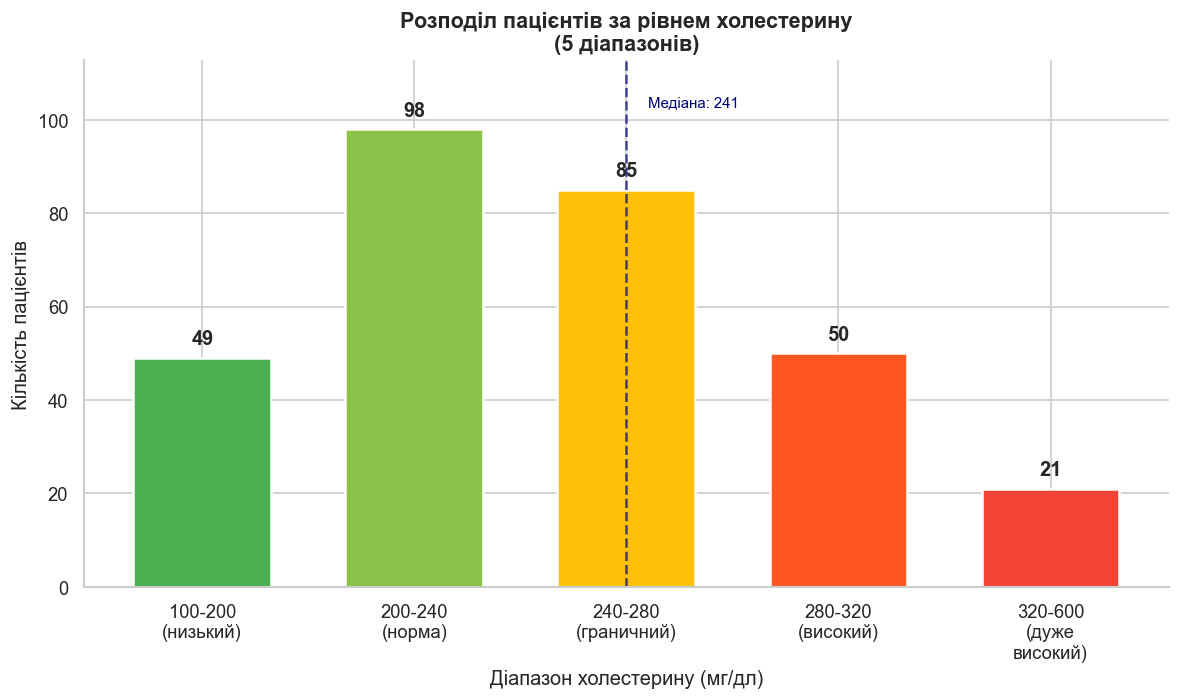

Графік збережено: plot2_histogram.png


In [9]:
bins = [100, 200, 240, 280, 320, 600]
labels = ['100-200\n(низький)', '200-240\n(норма)', '240-280\n(граничний)', 
          '280-320\n(високий)', '320-600\n(дуже\nвисокий)']
colors_hist = ['#4CAF50', '#8BC34A', '#FFC107', '#FF5722', '#F44336']

counts, _ = np.histogram(df['chol'], bins=bins)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, counts, color=colors_hist, edgecolor='white', linewidth=1.5, width=0.65)


for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Діапазон холестерину (мг/дл)', fontsize=12)
ax.set_ylabel('Кількість пацієнтів', fontsize=12)
ax.set_title('Розподіл пацієнтів за рівнем холестерину\n(5 діапазонів)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)


median_chol = df['chol'].median()

for i in range(len(bins)-1):
    if bins[i] <= median_chol < bins[i+1]:
        ax.axvline(x=i, color='navy', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(i + 0.1, max(counts) * 1.05, f'Медіана: {median_chol:.0f}', 
                color='navy', fontsize=9)
        break

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig('plot2_histogram.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot2_histogram.png')

## Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 
Pair Plo  матриця розсіювання
Violin Plot  порівняння розподілів

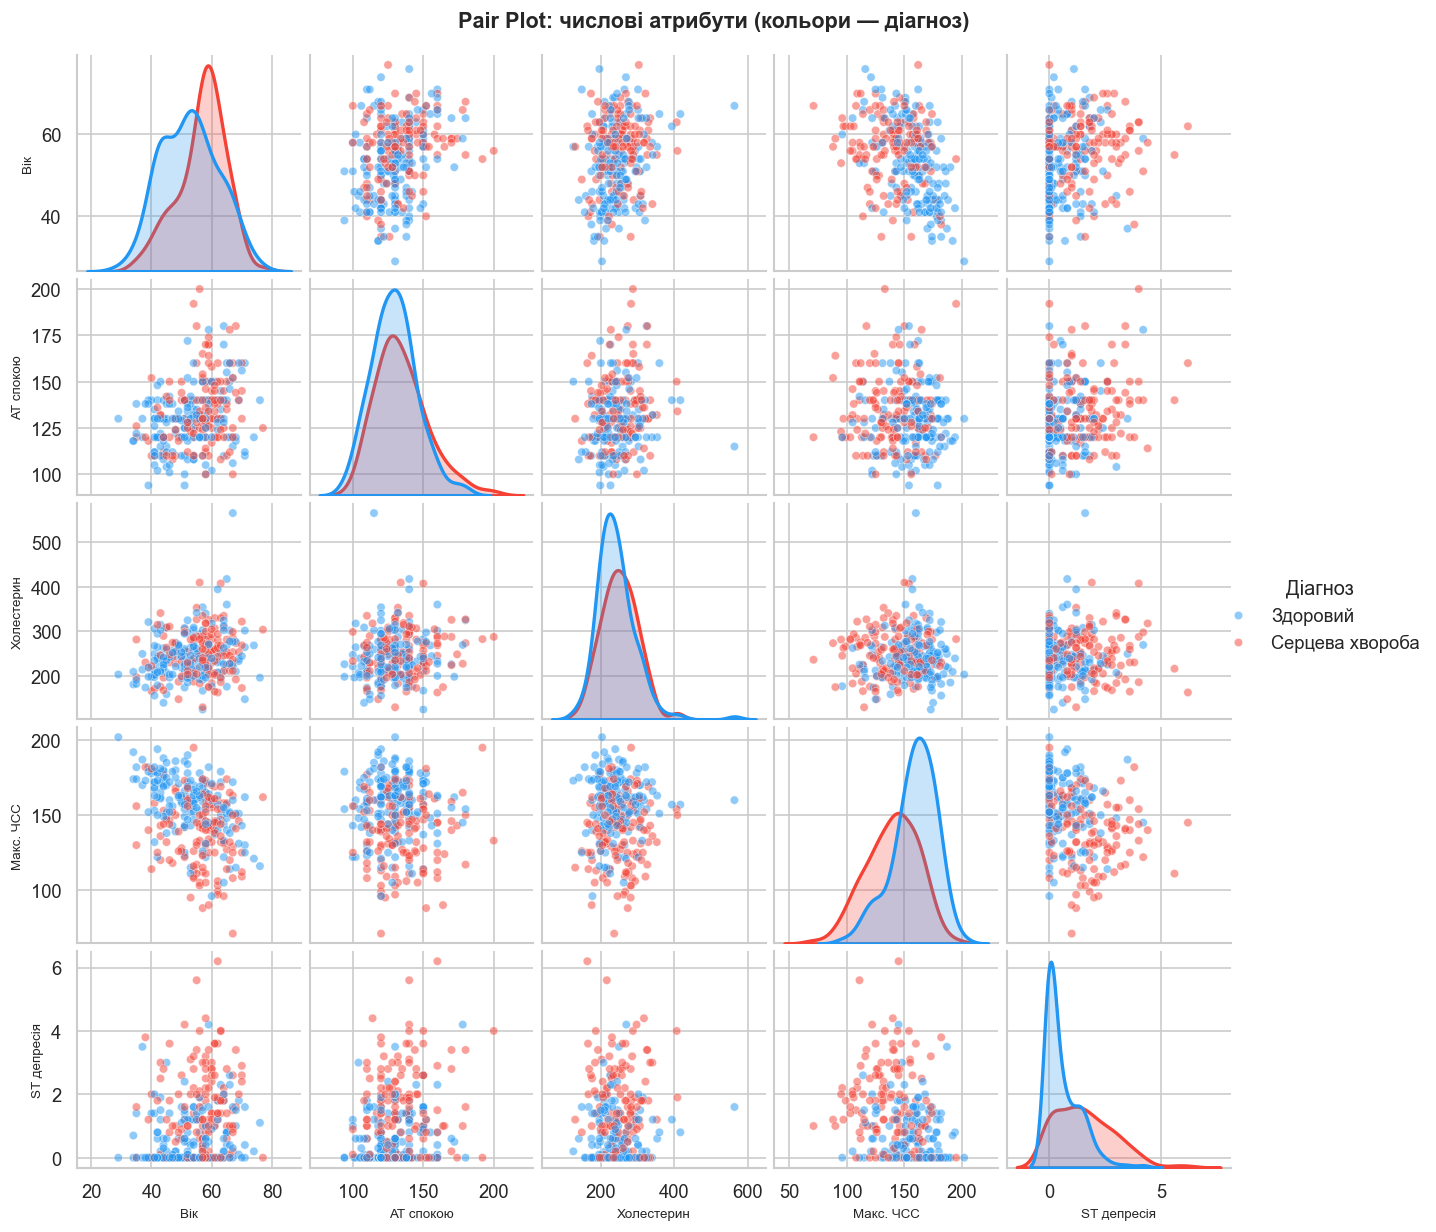

Графік збережено: plot3_pairplot.png


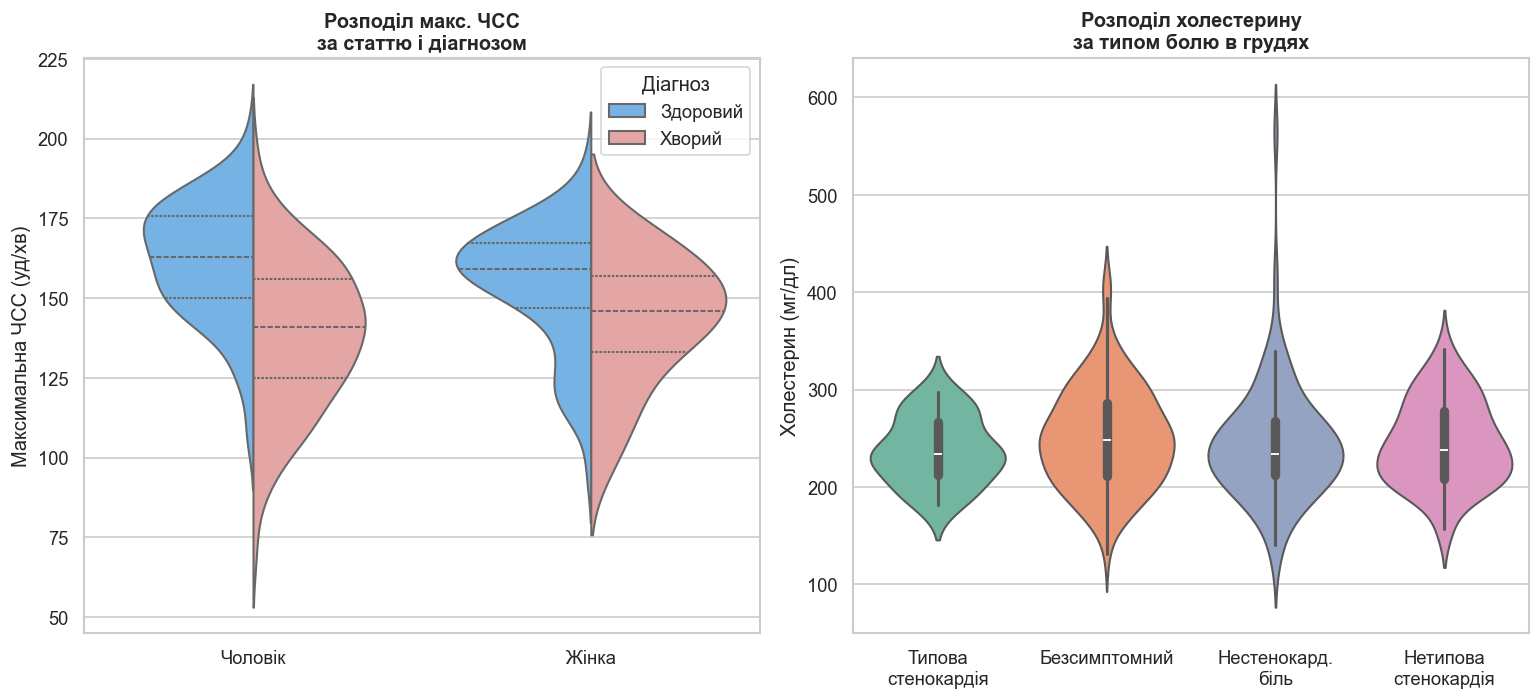

Графік збережено: plot4_violin.png


In [10]:

plot_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'disease']
pair_df = df[plot_cols].copy()
pair_df['Діагноз'] = pair_df['disease'].map({0: 'Здоровий', 1: 'Серцева хвороба'})

g = sns.pairplot(
    pair_df.drop('disease', axis=1),
    hue='Діагноз',
    palette={'Здоровий': '#2196F3', 'Серцева хвороба': '#F44336'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 25},
    diag_kws={'linewidth': 2}
)


labels_map = {
    'age': 'Вік', 'trestbps': 'АТ спокою', 'chol': 'Холестерин',
    'thalach': 'Макс. ЧСС', 'oldpeak': 'ST депресія'
}
for ax in g.axes.flat:
    if ax.get_xlabel() in labels_map:
        ax.set_xlabel(labels_map[ax.get_xlabel()], fontsize=8)
    if ax.get_ylabel() in labels_map:
        ax.set_ylabel(labels_map[ax.get_ylabel()], fontsize=8)

g.figure.suptitle('Pair Plot: числові атрибути (кольори — діагноз)', 
                  y=1.02, fontsize=13, fontweight='bold')
g.figure.set_size_inches(12, 10)
g.savefig('plot3_pairplot.png', bbox_inches='tight', dpi=100)
plt.show()
print('Графік збережено: plot3_pairplot.png')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

df_v = df.copy()
df_v['Стать'] = df_v['sex'].map({0: 'Жінка', 1: 'Чоловік'})
df_v['Діагноз'] = df_v['disease'].map({0: 'Здоровий', 1: 'Хворий'})


sns.violinplot(data=df_v, x='Стать', y='thalach', hue='Діагноз',
               split=True, inner='quart', ax=axes[0],
               palette={'Здоровий': '#64B5F6', 'Хворий': '#EF9A9A'})
axes[0].set_title('Розподіл макс. ЧСС\nза статтю і діагнозом', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Максимальна ЧСС (уд/хв)')
axes[0].set_xlabel('')


cp_map = {1: 'Типова\nстенокардія', 2: 'Нетипова\nстенокардія', 
          3: 'Нестенокард.\nбіль', 4: 'Безсимптомний'}
df_v['Тип болю'] = df_v['cp'].map(cp_map)

sns.violinplot(data=df_v, x='Тип болю', y='chol', ax=axes[1],
               palette='Set2', inner='box')
axes[1].set_title('Розподіл холестерину\nза типом болю в грудях', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Холестерин (мг/дл)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('plot4_violin.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot4_violin.png')

## Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.
Теплова карта кореляцій, Grouped Bar Chart: наявність хвороби за типом болю і статтю, Bubble Chart, Stacked Bar: тип болю за станом і діагнозом, Графік паралельних координат


## Теплова карта кореляцій

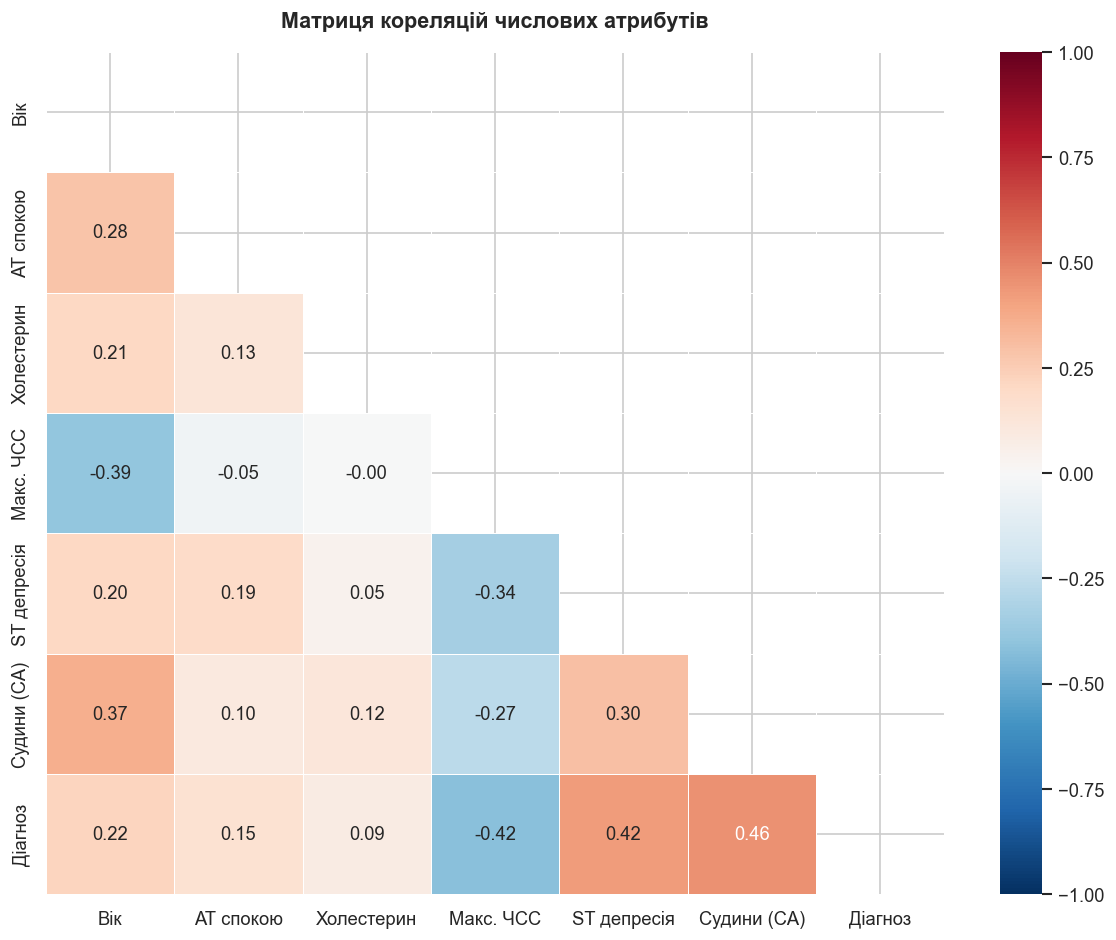

Графік збережено: plot5_heatmap.png


In [11]:

fig, ax = plt.subplots(figsize=(10, 8))

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'disease']
corr = df[num_cols].corr()

labels_corr = {
    'age': 'Вік', 'trestbps': 'АТ спокою', 'chol': 'Холестерин',
    'thalach': 'Макс. ЧСС', 'oldpeak': 'ST депресія',
    'ca': 'Судини (CA)', 'disease': 'Діагноз'
}
corr.index = [labels_corr[c] for c in corr.index]
corr.columns = [labels_corr[c] for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_title('Матриця кореляцій числових атрибутів', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot5_heatmap.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot5_heatmap.png')

## Grouped Bar Chart: наявність хвороби за типом болю і статтю

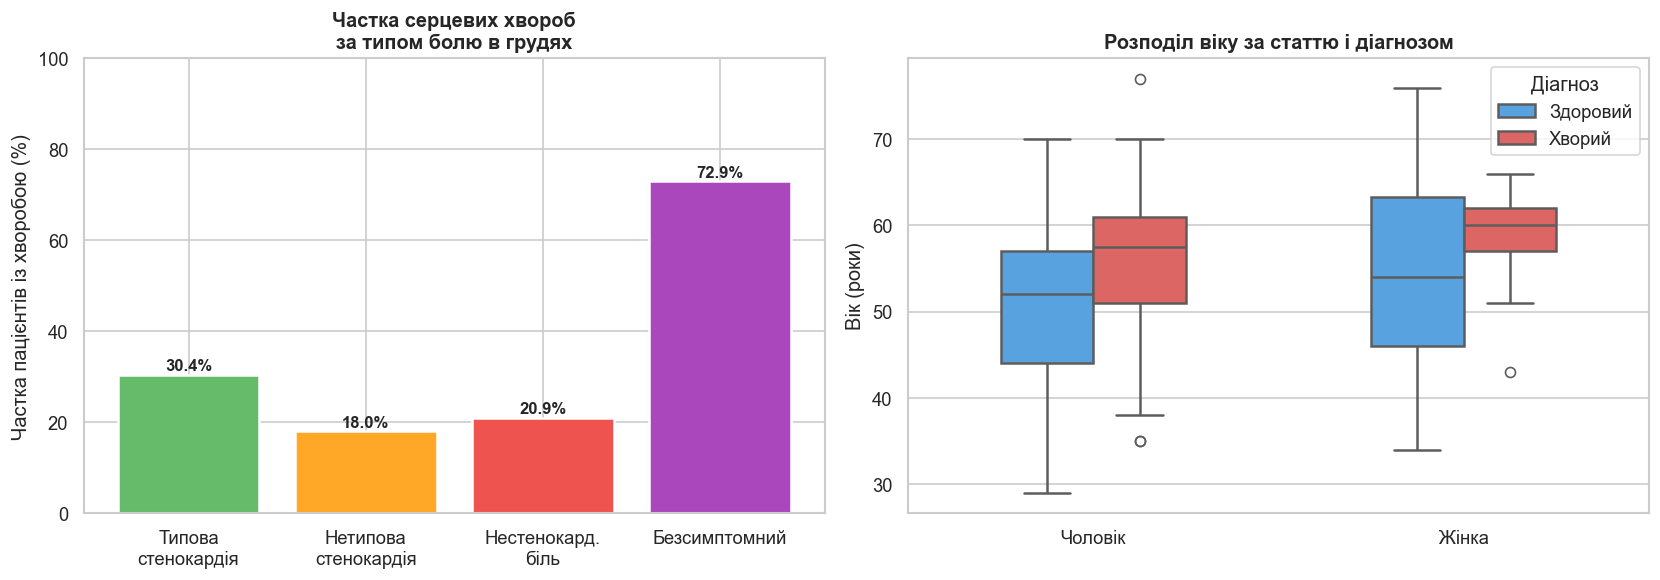

Графік збережено: plot6_bar_box.png


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cp_disease = df.groupby('cp')['disease'].agg(['sum', 'count'])
cp_disease['rate'] = cp_disease['sum'] / cp_disease['count'] * 100
cp_labels = ['Типова\nстенокардія', 'Нетипова\nстенокардія', 'Нестенокард.\nбіль', 'Безсимптомний']
cp_disease.index = cp_labels[:len(cp_disease)]

bars = axes[0].bar(cp_disease.index, cp_disease['rate'],
                   color=['#66BB6A', '#FFA726', '#EF5350', '#AB47BC'],
                   edgecolor='white', linewidth=1.5)
for bar, rate in zip(bars, cp_disease['rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[0].set_ylabel('Частка пацієнтів із хворобою (%)')
axes[0].set_title('Частка серцевих хвороб\nза типом болю в грудях', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)

sex_map = {0: 'Жінка', 1: 'Чоловік'}
df['Стать'] = df['sex'].map(sex_map)
df['Діагноз'] = df['disease'].map({0: 'Здоровий', 1: 'Хворий'})

sns.boxplot(data=df, x='Стать', y='age', hue='Діагноз',
            ax=axes[1], palette={'Здоровий': '#42A5F5', 'Хворий': '#EF5350'},
            width=0.5, linewidth=1.5)
axes[1].set_title('Розподіл віку за статтю і діагнозом', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Вік (роки)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('plot6_bar_box.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot6_bar_box.png')

## Bubble Chart (3D через розмір та колір)

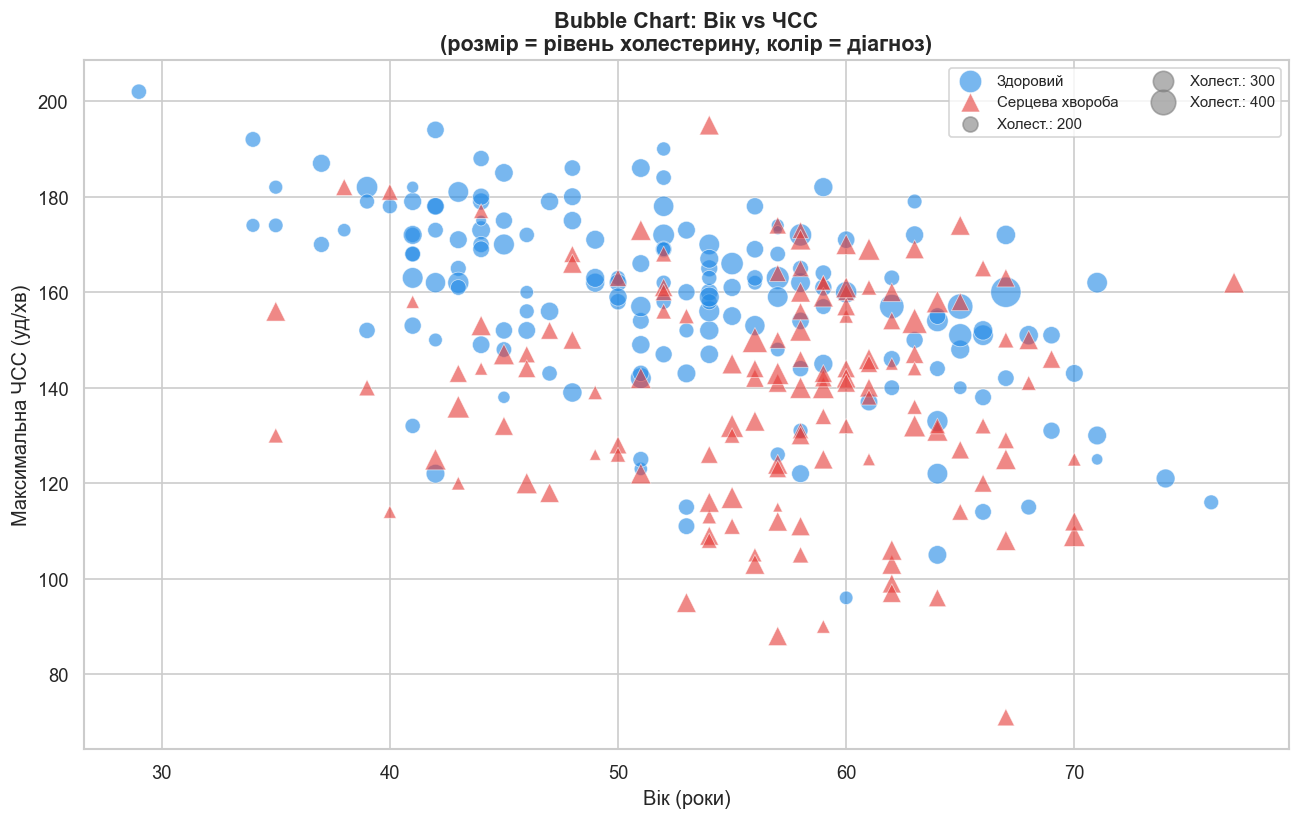

Графік збережено: plot7_bubble.png


In [13]:

fig, ax = plt.subplots(figsize=(11, 7))

for disease_val, color, label, marker in [
    (0, '#1E88E5', 'Здоровий', 'o'),
    (1, '#E53935', 'Серцева хвороба', '^')
]:
    subset = df[df['disease'] == disease_val]
    size = (subset['chol'] - df['chol'].min()) / (df['chol'].max() - df['chol'].min()) * 300 + 30
    ax.scatter(subset['age'], subset['thalach'],
               s=size, c=color, alpha=0.6, edgecolors='white',
               linewidth=0.5, marker=marker, label=label)

ax.set_xlabel('Вік (роки)', fontsize=12)
ax.set_ylabel('Максимальна ЧСС (уд/хв)', fontsize=12)
ax.set_title('Bubble Chart: Вік vs ЧСС\n(розмір = рівень холестерину, колір = діагноз)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)


for chol_val, label in [(200, '200'), (300, '300'), (400, '400')]:
    size_leg = (chol_val - df['chol'].min()) / (df['chol'].max() - df['chol'].min()) * 300 + 30
    ax.scatter([], [], s=size_leg, c='gray', alpha=0.6, label=f'Холест.: {chol_val}')
ax.legend(loc='upper right', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('plot7_bubble.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot7_bubble.png')

## Графік паралельних координат

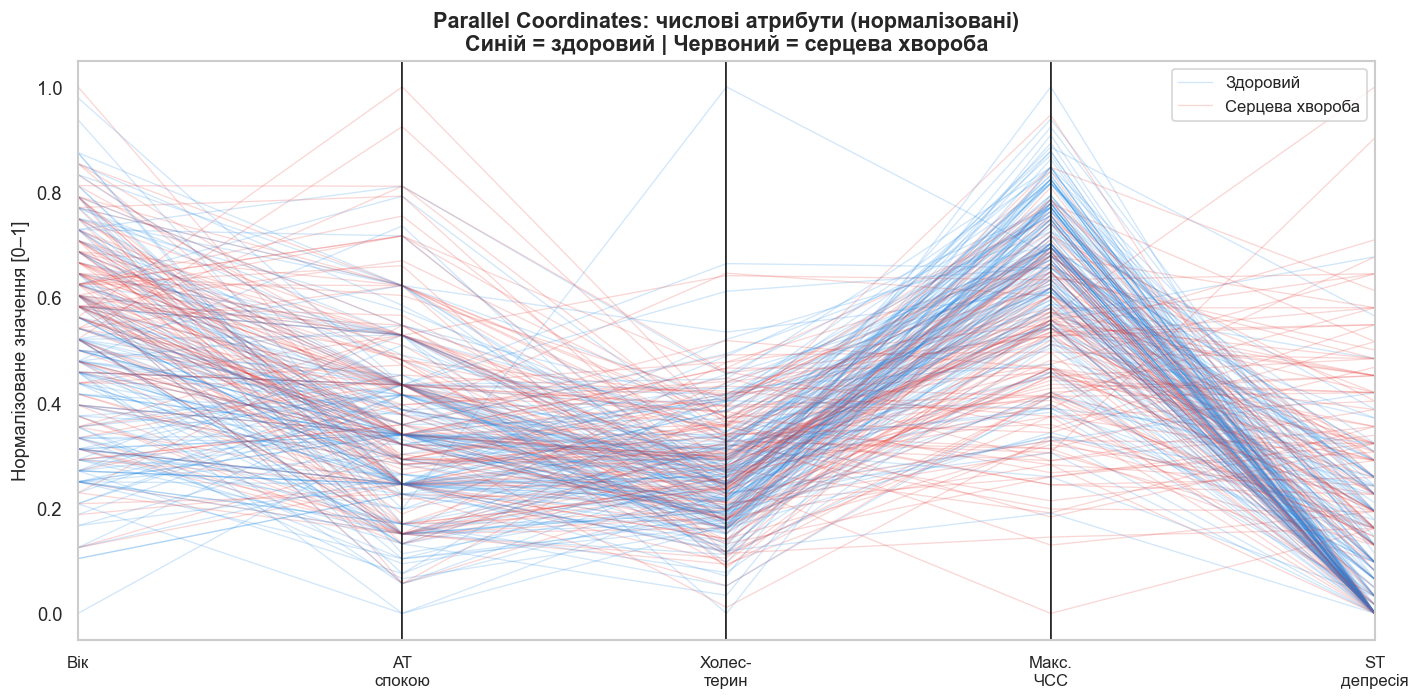

Графік збережено: plot9_parallel_coords.png


In [14]:

from pandas.plotting import parallel_coordinates

num_cols_pc = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_pc = df[num_cols_pc + ['Діагноз']].copy()

for col in num_cols_pc:
    df_pc[col] = (df_pc[col] - df_pc[col].min()) / (df_pc[col].max() - df_pc[col].min())


df_pc.rename(columns={
    'age': 'Вік', 'trestbps': 'АТ\nспокою', 'chol': 'Холес-\nтерин',
    'thalach': 'Макс.\nЧСС', 'oldpeak': 'ST\nдепресія'
}, inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))

parallel_coordinates(
    df_pc, class_column='Діагноз',
    color=['#1E88E5', '#E53935'],
    alpha=0.2, linewidth=0.8,
    ax=ax
)

ax.set_title('Parallel Coordinates: числові атрибути (нормалізовані)\n'
             'Синій = здоровий | Червоний = серцева хвороба',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Нормалізоване значення [0–1]', fontsize=11)
ax.set_xlabel('')
ax.legend(['Здоровий', 'Серцева хвороба'], fontsize=10, loc='upper right')
ax.tick_params(axis='x', labelsize=10)


for xc in range(len(df_pc.columns) - 1):
    ax.axvline(x=xc, color='gray', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('plot9_parallel_coords.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot9_parallel_coords.png')

## Stacked Bar: тип болю за станом і діагнозом

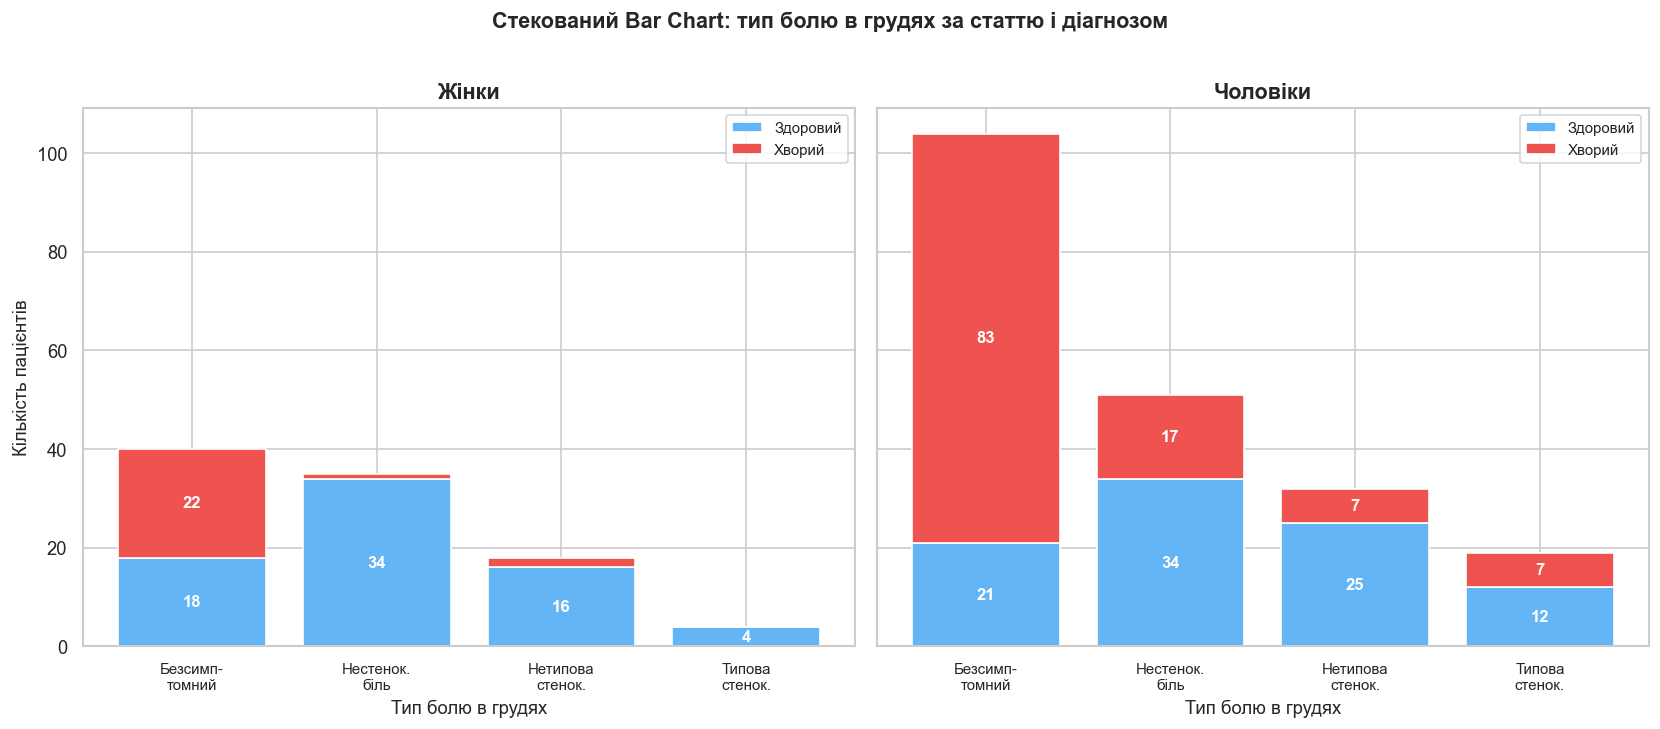

Графік збережено: plot8_stacked_bar.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
cp_labels = {1: 'Типова\nстенок.', 2: 'Нетипова\nстенок.', 
             3: 'Нестенок.\nбіль', 4: 'Безсимп-\nтомний'}
df['cp_label'] = df['cp'].map(cp_labels)
df['Стать'] = df['sex'].map({0: 'Жінка', 1: 'Чоловік'})
df['Діагноз'] = df['disease'].map({0: 'Здоровий', 1: 'Хворий'})

colors_diag = {'Здоровий': '#64B5F6', 'Хворий': '#EF5350'}

for ax, (sex_label, sex_val) in zip(axes, [('Жінки', 0), ('Чоловіки', 1)]):
    subset = df[df['sex'] == sex_val]

    counts = subset.groupby(['cp_label', 'Діагноз'], observed=True).size().unstack(fill_value=0)

    bottom = np.zeros(len(counts))
    for diag, color in colors_diag.items():
        if diag in counts.columns:
            vals = counts[diag].values
            bars = ax.bar(counts.index, vals, bottom=bottom, 
                          label=diag, color=color, edgecolor='white', linewidth=1)

            for bar, val, bot in zip(bars, vals, bottom):
                if val > 2:
                    ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                            str(int(val)), ha='center', va='center',
                            fontsize=10, fontweight='bold', color='white')
            bottom += vals
    
    ax.set_title(f'{sex_label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Тип болю в грудях', fontsize=11)
    ax.set_ylabel('Кількість пацієнтів', fontsize=11) if ax == axes[0] else None
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Стекований Bar Chart: тип болю в грудях за статтю і діагнозом',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('plot8_stacked_bar.png', bbox_inches='tight')
plt.show()
print('Графік збережено: plot8_stacked_bar.png')